Analyst : Talabong, Catherine A.

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

In [2]:
dengue = pd.read_csv('dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [3]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [4]:
dengue['Region'] = dengue['Region'].astype('category')
dengue['Month'] = dengue['Month'].astype('category')
dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
dtype: object

In [5]:
#Dengue cases per region...
dengue['Region'].value_counts()

Region
BARMM          60
Region V       60
Region XII     60
Region XI      60
Region X       60
Region VIII    60
Region VII     60
Region VI      60
Region IX      60
CAR            60
Region IV-B    60
Region IV-A    60
Region III     60
Region II      60
Region I       60
NCR            60
Region XIII    60
Name: count, dtype: int64

In [6]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h1>Yearly Dengue Cases & Dengue Deaths</h1>

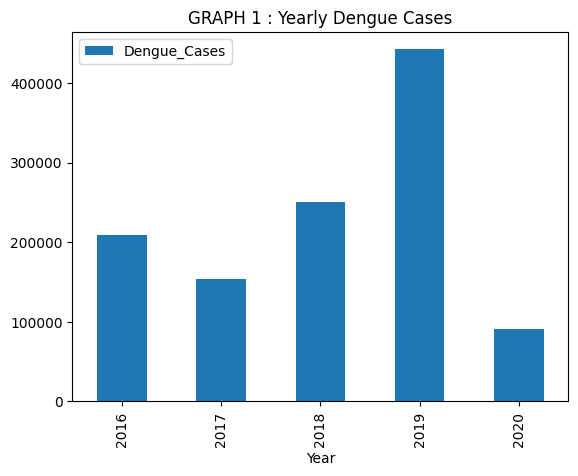

      Dengue_Cases
Year              
2016        209544
2017        154155
2018        250783
2019        441902
2020         91041


In [7]:
Y_DengueCases = dengue.groupby('Year')[['Dengue_Cases']].sum()
Y_DengueCases.plot(kind='bar', title='GRAPH 1 : Yearly Dengue Cases')
plt.show()
print(Y_DengueCases)

<h2>INSIGHTS: Dengue Cases Yearly</h2><hr>
<h3>
- This are the Yearly counts of Dengue Cases from 2016 - 2020:<br> 209544 <i>(2016)</i>, 154155 <i>(2017)</i>, 250783 <i>(2018)</i>, 441902 <i>(2019)</i>, 91041 <i>(2020)</i>.
</h3>
<h3>
- As for the trend. From the 209544 cases in 2016, it drops to 154155 cases in 2017. It continue rises on 2018 with 250783 cases and almost doubled the cases of 2016 with 441902 cases in 2019. In 2020, it drops lower than the year 2017 with 91041 cases.
</h3>

      Dengue_Deaths
Year               
2016           8127
2017           4563
2018           1226
2019           1733
2020           1195


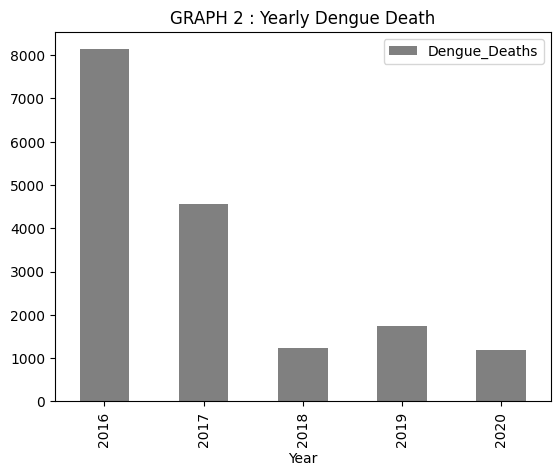

In [8]:
Y_DengueDeath = dengue.groupby('Year')[['Dengue_Deaths']].sum()
Y_DengueDeath.plot(kind='bar', title='GRAPH 2 : Yearly Dengue Death', color = 'Gray')
print(Y_DengueDeath)
plt.show()

<h2>INSIGHTS: Dengue Deaths Yearly</h2><hr>
<h3>
- This are the Yearly counts of Dengue Death from 2016 - 2020: 8127 <i>(2016)</i>, 4563 <i>(2017)</i>, 1226 <i>(2018)</i>, 1733 <i>(2019)</i>, 1195 <i>(2020)</i>.
</h3>
<h3>
- As for the trend. From the 8126 deaths in 2016, it drops to 4563 deaths in 2017 and continues to drop on 2018 with 1226 deaths. It slightly rises in 2019 with 1733 deaths but decreases again in the next year 2020 with 1195 deaths.
</h3>

   Year  Dengue_Cases
0  2016        209544
1  2017        154155
2  2018        250783
3  2019        441902
4  2020         91041


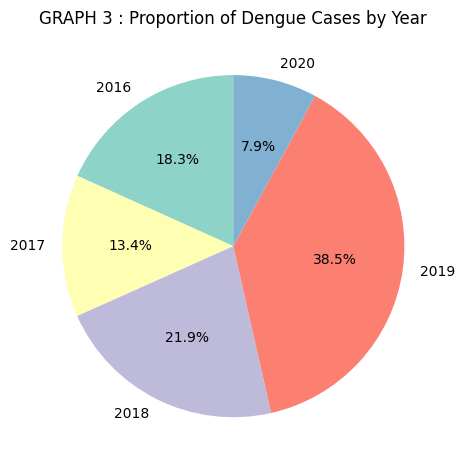

   Year  Dengue_Deaths
0  2016           8127
1  2017           4563
2  2018           1226
3  2019           1733
4  2020           1195


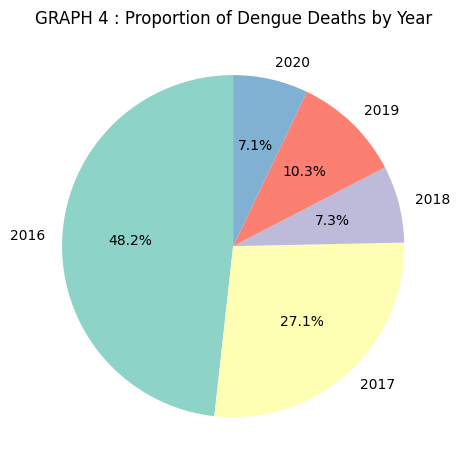

In [9]:
yearly_cases = dengue.groupby('Year')['Dengue_Cases'].sum().reset_index()
print(yearly_cases)
plt.pie(yearly_cases['Dengue_Cases'], labels=yearly_cases['Year'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('GRAPH 3 : Proportion of Dengue Cases by Year')
plt.tight_layout()
plt.show()

yearly_deaths = dengue.groupby('Year')['Dengue_Deaths'].sum().reset_index()
print(yearly_deaths)
plt.pie(yearly_deaths['Dengue_Deaths'], labels=yearly_deaths['Year'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('GRAPH 4 : Proportion of Dengue Deaths by Year')
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Proportion of Dengue Cases & Deaths Yearly</h2><hr>
<h3>- The year 2019 got the highest percentage with 38.5% (441902) Recorded Cases. 2nd to highest is 2018 with 21.9%(250783). 3rd is 2016 with 18.3% (209544). 4th is 2017 with 13.4% (152155). While the year 2020 has the lowest number of cases with 7.9% (91041) Recorded Cases.</h3>

<h3>- The year 2016 got the highest number of deaths among other Years with 48.2% (8126) Recorded Deaths. 2nd is 2017 with 27.1% (4563 Deaths). 3rd is 2019 with 10.3% (1733 Deaths). 4th is 2018 with 7.3% (1226 Deaths). While the year 2020 has the lowest number of Deaths with 7.1% (1195) Recorded Deaths.</h3>

<h1>Monthly Dengue Cases & Deaths</h1>

          Dengue_Cases                            
Year              2016   2017   2018   2019   2020
Month                                             
January          17052  15623  12657  20672  18324
February         12386   9872  10466  25494  19583
March             9300   7696   7944  19798  12838
April             7269   6343   6860   9252   2784
May               8092   4853   6594  10387   2461
June             10831   7589  11502  25523   2665
July             29744  18340  30363  55220   4575
August           36195  25039  34210  85038   7072
September        26990  17753  38617  89642   4941
October          21943  15259  30026  46382   4035
November         16252  12553  30191  30097   5807
December         13490  13235  31353  24397   5956


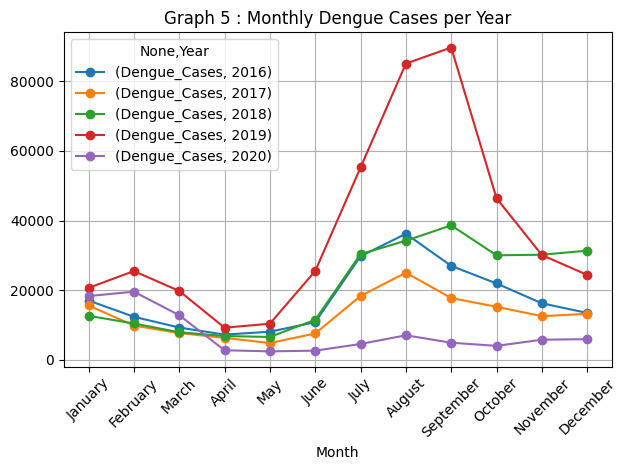

Axes(0.107183,0.225933;0.857098x0.696289)


In [10]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']

dengue_monthly_cases = dengue.groupby(['Month','Year'])[['Dengue_Cases']].sum().unstack('Year').reindex(month_order)
print(dengue_monthly_cases)
dengue_monthly_cases = dengue_monthly_cases.plot(marker='o', title='Graph 5 : Monthly Dengue Cases per Year', grid=True, label=True)
dengue_monthly_cases.set_xticks(range(len(month_order)))
dengue_monthly_cases.set_xticklabels(month_order, rotation=45)
plt.tight_layout()
plt.show()
print(dengue_monthly_cases)

<h2>INSIGHTS: Total Monthly Dengue Cases per Year</h2><hr>
<h3>
- The Month of September in 2019 got the highest number of cases with 89642 recorded cases. While the Month of May in 2020 got the lowest number of cases with 2461 Recorded Cases.
</h3>
<h3>
- For the every Year:<br>
    In 2016, the month who got the highest number of cases is August with 36195 cases, while the month of April got 7269 cases. <br>
    In 2017, the month who got the highest number of cases is August with 25039 cases, while the month of May got 4853 cases. <br>
    In 2018, the month who got the highest number of cases is September with 38617 cases, while the month of April got 6860 cases. <br>
    In 2019, the month who got the highest number of cases is September with 89642 cases, while the month of April got 9252 cases. <br>
    In 2020, the month who got the highest number of cases is February with 19583 cases, while the month of May got 2461 cases. <br>
</h3>
<h3>
In summary from the year 2016 upto 2020, the months who have highest recorded cases in dengue per year are August & September in 2016-2017, 2018-2019 (respectively) and the month of February in the year 2020. While the months who got low recorded casess in dengue are April in 2016, 2019 & 2019 and the month of May in the year 2017 & 2020.
</h3>

          Dengue_Deaths                     
Year               2016  2017 2018 2019 2020
Month                                       
January              73    95   65   94   67
February             43    64   43  101   64
March                47    36   58  103   47
April                40    43   41   59   17
May                  41    23   31   56   11
June                 69    42   78  119   14
July                123    74  153  232   29
August              132   111  156  280   35
September          3418  1826  185  377  342
October            3954  2098  150  133  335
November            104    78  131   88  212
December             83    73  135   91   22


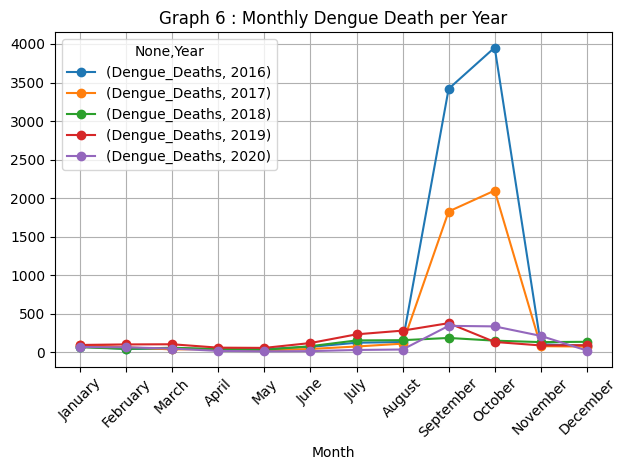

In [11]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']

dengue_monthly_death = dengue.groupby(['Month','Year'])[['Dengue_Deaths']].sum().unstack('Year').reindex(month_order)
print(dengue_monthly_death)

dengue_monthly_death = dengue_monthly_death.plot(marker='o', title='Graph 6 : Monthly Dengue Death per Year', grid=True)
dengue_monthly_death.set_xticks(range(len(month_order)))
dengue_monthly_death.set_xticklabels(month_order, rotation=45)
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Monthly Dengue Deaths per Year</h2><hr>
<h3>
- The Month of October in 2016 got the highest number of cases with 3954 Recorded Deaths While the Month of May in 2020 got the lowest number of cases with 11 Recorded Deaths.
</h3>
<h3>
- For the every Year:<br>
    In 2016, the month who got the highest number of cases is October with 3954 deaths, while the month of April got 40 deaths. <br>
    In 2017, the month who got the highest number of cases is October with 2098 deaths, while the month of May got 23 deaths. <br>
    In 2018, the month who got the highest number of cases is September with 185 cases, while the month of May got 31 cases. <br>
    In 2019, the month who got deaths highest number of cases is September with 377 deaths, while the month of May got 56 deaths <br>
    In 2020, the month who got the highest number of cases is September with 342 deaths, while the month of May got 11 cases.</h3>
<h3>
In summary from the year 2016 upto 2020, the months of October got 2 years (2016, 2017) highest recorded deaths & September got 3 years (2018, 2019, 2020) with highest recorded deaths. While the months who got low recorded deaths in dengue are April in 2016 and May in the 4 years (2017, 2018, 2019, 2020)
</h3>

           Dengue_Cases
Month                  
January           84328
February          77801
March             57576
April             32508
May               32387
June              58110
July             138242
August           187554
September        177943
October          117645
November          94900
December          88431


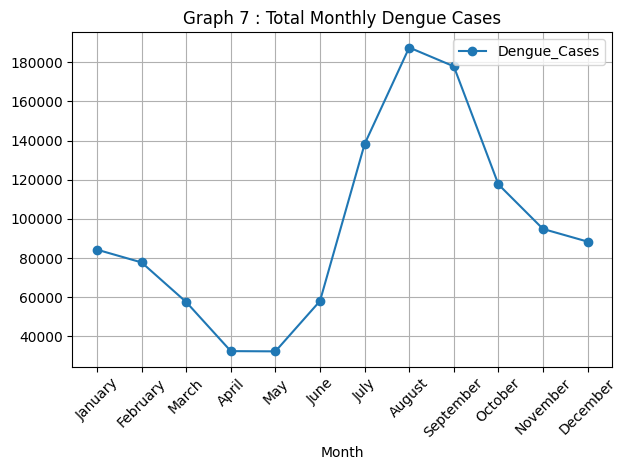

In [12]:
total_monthly_cases = dengue.groupby('Month')[['Dengue_Cases']].sum().reindex(month_order)
print(total_monthly_cases)

total_monthly_cases = total_monthly_cases.plot(marker='o', title='Graph 7 : Total Monthly Dengue Cases', grid=True, legend=True)
total_monthly_cases.set_xticks(range(len(month_order)))
total_monthly_cases.set_xticklabels(month_order, rotation=45)
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Total Monthly Dengue Cases</h2><hr>
<h3>
- This are the Monthly counts of Dengue Cases:<br> 84328 <i>(January)</i>, 77801 <i>(Febuary)</i>, 57576 <i>(March)</i>, 32508 <i>(April)</i>, 32387 <i>(May)</i>, 58110 <i>(June)</i>, 138242 <i>(July)</i>, 187554 <i>(August)</i>, 177943 <i>(September)</i>, 117645 <i>(October)</i>, 94900 <i>(November)</i>, 88431 <i>(December)</i>.
</h3>
<h3>
- The Month of August got the highest number of cases with 187554 Recorded Cases. While the Month of May got the lowest number of cases with 32387 Recorded Cases.
</h3>
<h3>
- As for the trend. From the month of January with cases of 84328, it decreases upto the month of May with 32387. The cases increase on the month of June with 58110 and got massive increase upto August with 187554. As for the months of September to December, it decreases upto 8431 cases.
</h3>

           Dengue_Deaths
Month                   
January              394
February             315
March                291
April                200
May                  162
June                 322
July                 611
August               714
September           6148
October             6670
November             613
December             404


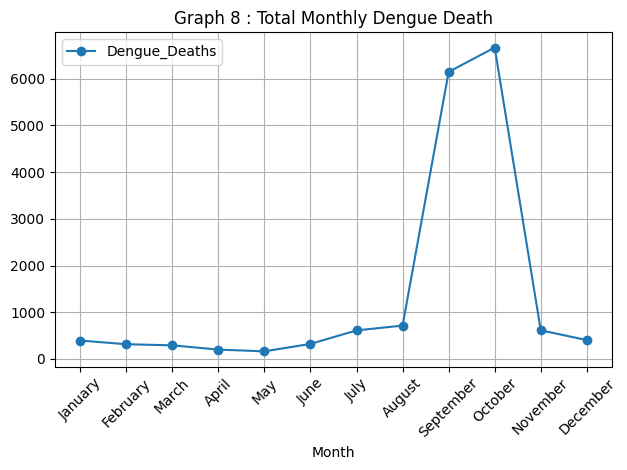

In [13]:
total_monthly_death = dengue.groupby('Month')[['Dengue_Deaths']].sum().reindex(month_order)
print(total_monthly_death)

total_monthly_death = total_monthly_death.plot(marker='o', title='Graph 8 : Total Monthly Dengue Death', grid=True)
total_monthly_death.set_xticks(range(len(month_order)))
total_monthly_death.set_xticklabels(month_order, rotation=45)
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Total Monthly Dengue Deaths</h2><hr>
<h3>
- This are the Monthly counts of Dengue Cases:<br> 394 <i>(January)</i>, 315 <i>(Febuary)</i>, 291 <i>(March)</i>, 200 <i>(April)</i>, 162 <i>(May)</i>, 322 <i>(June)</i>, 611 <i>(July)</i>, 714 <i>(August)</i>, 6148 <i>(September)</i>, 6670 <i>(October)</i>, 613 <i>(November)</i>, 404 <i>(December)</i>.
</h3>
<h3>
- The Month of October got the highest number of deaths with 6670 Recorded Cases. While the Month of May got the lowest number of cases with 162 Recorded Cases.
</h3>
<h3>
- As for the trend. From the month of January with deaths of 394, it is slowly decreasing upto the month of May with 162 deaths. The deaths slowly increasing on the months of June, July & August with 714 deaths then got amassive increase on September with 6148 death. Little of increasin October with 6670 deaths. On the month of November, death counts got a massive decrease with 613 deaths and December with 404 deaths.
</h3>

           Dengue_Deaths  Dengue_Cases
Month                                 
January              394         84328
February             315         77801
March                291         57576
April                200         32508
May                  162         32387
June                 322         58110
July                 611        138242
August               714        187554
September           6148        177943
October             6670        117645
November             613         94900
December             404         88431


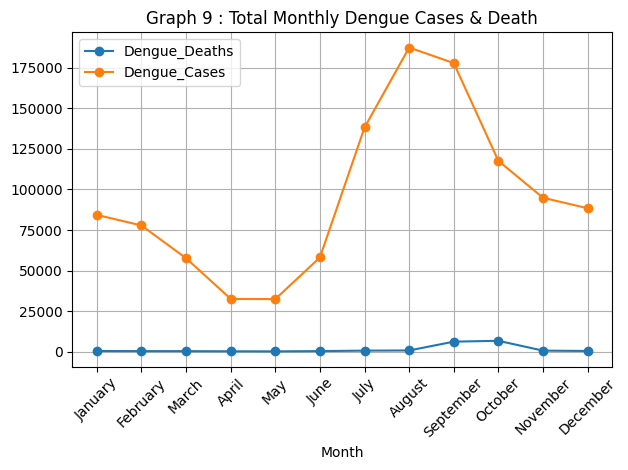

In [14]:
total_monthly_death = dengue.groupby(['Month'])[['Dengue_Deaths','Dengue_Cases']].sum().reindex(month_order)
print(total_monthly_death)

total_monthly_death = total_monthly_death.plot(marker='o', title='Graph 9 : Total Monthly Dengue Cases & Death', grid=True)
total_monthly_death.set_xticks(range(len(month_order)))
total_monthly_death.set_xticklabels(month_order, rotation=45)
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Total Monthly Dengue Cases & Deaths</h2><hr>
<h3>
- We can see in the graph that even if the cases goes up or down, the number of deaths are uncertain.
</h3>

<h2>Regional Dengue Cases</h2>

In [15]:
region_to_island = {
    'CAR': 'Luzon',
    'Region I': 'Luzon',
    'Region II': 'Luzon',
    'Region III': 'Luzon',
    'NCR': 'Luzon',
    'Region IV-A': 'Luzon',
    'Region IV-B': 'Luzon',
    'Region V': 'Luzon',
    'Region VI': 'Visayas',
    'Region VII': 'Visayas',
    'Region VIII': 'Visayas',
    'Region IX': 'Mindanao',
    'Region X': 'Mindanao',
    'Region XI': 'Mindanao',
    'Region XII': 'Mindanao',
    'Region XIII': 'Mindanao',
    'BARMM': 'Mindanao'}

dengue['Island'] = dengue['Region'].map(region_to_island)

dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
Island             object
dtype: object

             Dengue_Cases
Region                   
CAR                509.70
Region I           984.43
Region II          752.35
Region III        2184.40
NCR               1932.77
Region IV-A       2717.15
Region IV-B        514.15
Region V           369.45
Region VI         1958.72
Region VII        1844.72
Region VIII        866.38
Region IX          796.35
Region X          1373.95
Region XI          542.03
Region XII         996.70
Region XIII        588.22
BARMM              192.28


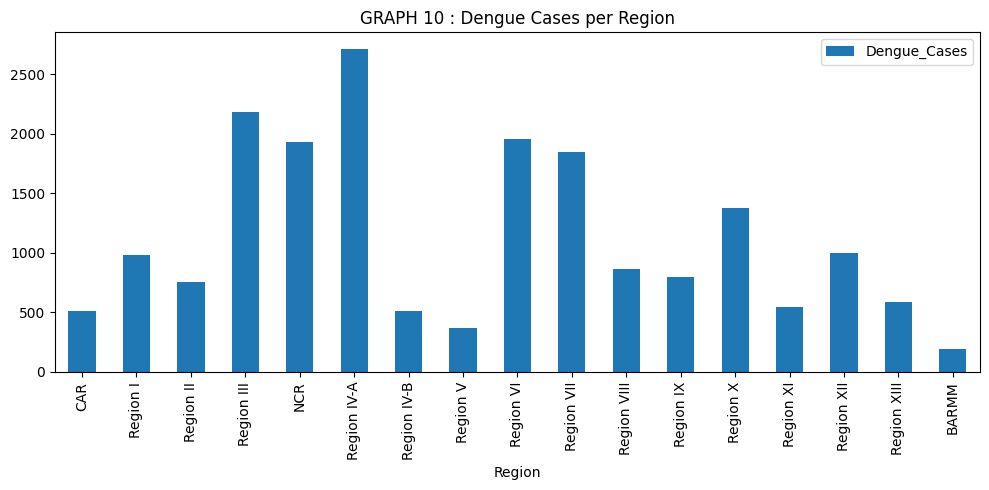

In [16]:
region_order = ['CAR','Region I','Region II','Region III','NCR','Region IV-A','Region IV-B','Region V','Region VI','Region VII','Region VIII','Region IX','Region X','Region XI','Region XII','Region XIII','BARMM']

dengue_region_cases = dengue.groupby('Region')[['Dengue_Cases']].mean().round(2).reindex(region_order)
print(dengue_region_cases)
dengue_region_cases=dengue_region_cases.plot(kind='bar', figsize=(10,5), title='GRAPH 10 : Dengue Cases per Region')
dengue_region_cases.set_xticks(range(len(region_order)))
dengue_region_cases.set_xticklabels(region_order)
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Dengue Cases per Region</h2><hr>
<h3>- Region IV-A got the highest average recorded dengue cases per region with 2717. And the Region of BARMM got the lowest average with 192.28</h3>

             Dengue_Deaths
Region                    
CAR                  16.80
Region I              2.62
Region II             3.22
Region III            8.03
NCR                  66.80
Region IV-A          10.87
Region IV-B           2.17
Region V              3.08
Region VI            30.42
Region VII           29.33
Region VIII           9.75
Region IX             8.87
Region X             14.13
Region XI             6.42
Region XII           46.60
Region XIII          16.10
BARMM                 5.53


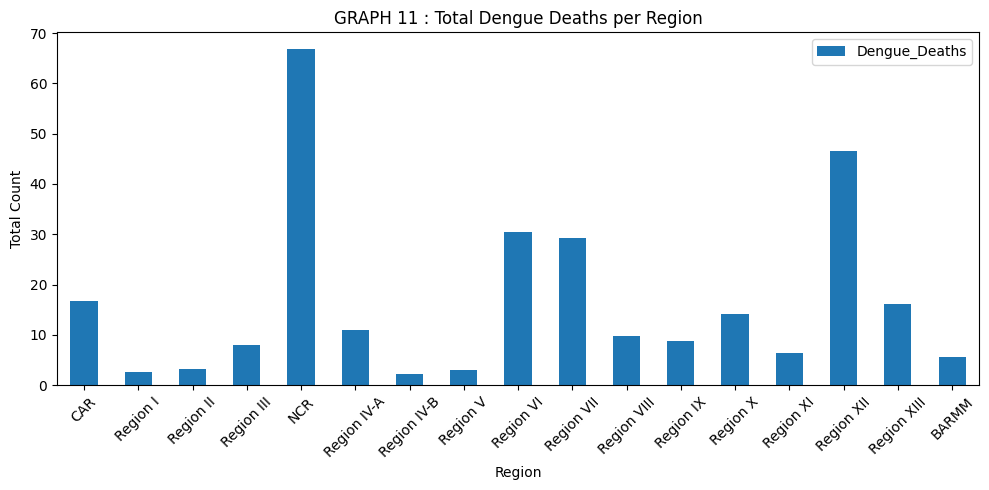

In [17]:
total_deaths = dengue.groupby('Region')[['Dengue_Deaths']].mean().round(2).reindex(region_order)
print(total_deaths)

total_deaths = total_deaths.plot(kind='bar', figsize=(10, 5), title='GRAPH 11 : Total Dengue Deaths per Region')
total_deaths.set_xticks(range(len(region_order)))
total_deaths.set_xticklabels(region_order, rotation=45)
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

<h2>INSIGHTS: Dengue Deaths per Region</h2><hr>
<h3>- NCR got the highest average recorded dengue deaths per region with 66.80, And the Region IV-B got the lowest average of recorded deaths of 2.17.</h3>

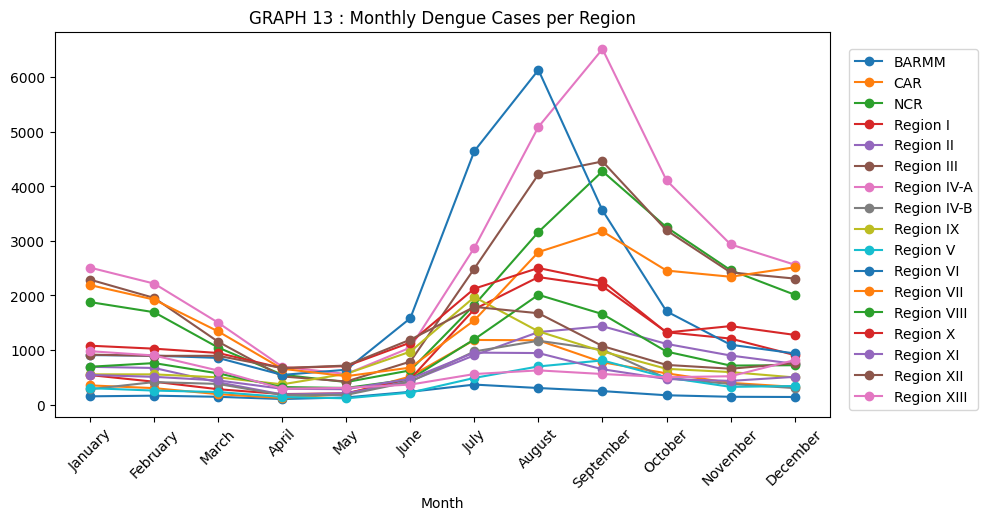

In [18]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

mon_dengue_region = dengue.groupby(['Region', 'Month'])['Dengue_Cases'].mean().unstack('Region').reindex(month_order).plot(marker='o', figsize=(10,5), title='Monthly Dengue Patterns by Region')
mon_dengue_region.set_title('GRAPH 13 : Monthly Dengue Cases per Region')
mon_dengue_region.set_xticks(range(len(month_order)))
mon_dengue_region.set_xticklabels(month_order, rotation=45)
plt.legend(loc='lower right', bbox_to_anchor=(1.2, 0))
plt.show()

<h2>INSIGHTS: Monthly Dengue Cases per Region</h2><hr>
<h3>- Among the Regions, Region IV-A got the highest recorded monthly dengue cases in the month of September.</h3>
<h3>- We can also see that there are some pattern in the graph. From January it decreases upto the months of April or May, then increase upto the months of August or September, then decreases again upto the month of December.</h3>

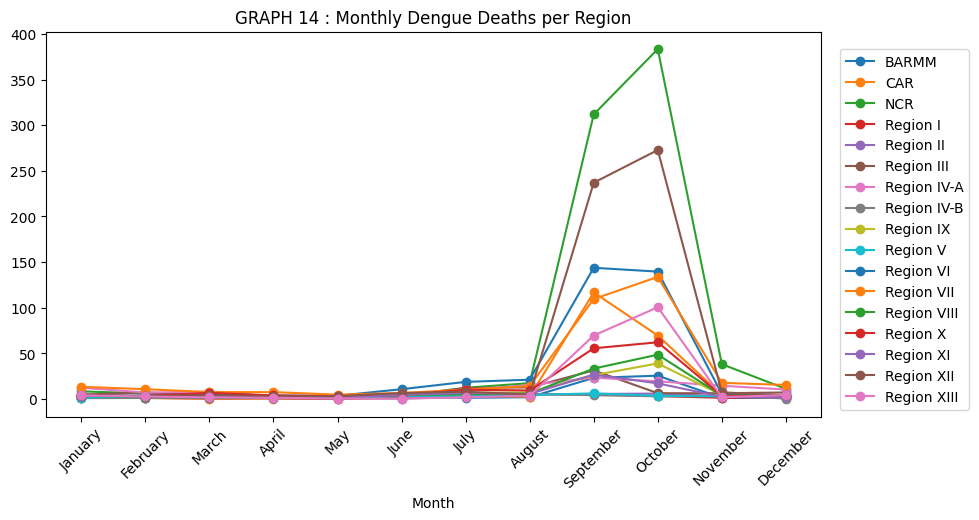

In [19]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

mon_dengue_region = dengue.groupby(['Region', 'Month'])['Dengue_Deaths'].mean().unstack('Region').reindex(month_order).plot(marker='o', figsize=(10,5), title='Monthly Dengue Patterns by Region')
mon_dengue_region.set_title('GRAPH 14 : Monthly Dengue Deaths per Region')
mon_dengue_region.set_xticks(range(len(month_order)))
mon_dengue_region.set_xticklabels(month_order, rotation=45)
plt.legend(loc='lower right', bbox_to_anchor=(1.2, 0))
plt.show()

<h2>INSIGHTS: Monthly Dengue Deaths per Region</h2><hr>
<h3>- on the graph, there are a massive increase of dengue deaths when months of September and October comes.</h3>
<h3>- In total number of deaths per month, NCR got the highest recorded dengue deaths.</h3>

In [20]:
dengue.groupby(['Region', 'Year'])[['Dengue_Cases', 'Dengue_Deaths']].sum().sort_values(by='Dengue_Cases', ascending=False).head(10)

Dengue_Cases  Dengue_Deaths
Region      Year                             
Region IV-A 2019         76195            242
Region VI   2019         60357            233
NCR         2019         40478            190
Region III  2019         37158            194
            2018         31726             85
Region VII  2019         31053            143
Region IV-A 2018         30410            157
Region VII  2016         29395            243
NCR         2018         29200            180
Region X    2019         28356             95

<h1>Relationships</h1>

In [21]:
correlation = dengue['Dengue_Cases'].corr(dengue['Dengue_Deaths'])
print(f"Correlation between cases and deaths: {correlation:.2f}")

Correlation between cases and deaths: 0.04


<h2>INSIGHTS: Dengue Deaths per Region</h2><hr>
<h3>- The correlation of Dengue Cases and Dengue Deaths are 0.04, which means they are not related.</h3>

<hr>
<h1>THANK YOU!</h1>
<hr>